# Experimental Rigor Analysis

This notebook evaluates the robustness and reliability of the model through:

1.Data Splitting Strategy

2.Convergence Analysis

3.Overfitting Analysis

4.Cross-Validation

5.Performance Comparison

6.Generalisation Performance


In [81]:
import torch
import torch.nn as nn

class BottleCNN(nn.Module):
    def __init__(self):
        super(BottleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [82]:
def train_model_batch_acc(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_losses.append(total_loss / len(train_loader))
        train_accs.append(correct / total)

        # Validation
        model.eval()
        val_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(correct / total)

    return train_losses, val_losses, train_accs, val_accs

In [83]:
model = BottleCNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs = train_model_batch_acc(model, optimizer)

In [84]:


# Load test data (if not already loaded)
X_test = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

# Convert to torch tensors
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_test = torch.tensor(y_test, dtype=torch.long)

# Set model to evaluation mode
model.eval()

correct = 0
total = 0

with torch.no_grad():
    outputs = model(X_test)
    _, preds = torch.max(outputs, 1)

    correct += (preds == y_test).sum().item()
    total += y_test.size(0)

test_accuracy = correct / total

print("Test Accuracy (CNN):", test_accuracy)

Test Accuracy (CNN): 0.926829268292683


## Data Splitting

In [62]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

import torch
import torch.nn as nn
import torch.optim as optim


In [63]:
X_train = np.load("../dataset/X_train.npy")
y_train = np.load("../dataset/y_train.npy")

X_val = np.load("../dataset/X_val.npy")
y_val = np.load("../dataset/y_val.npy")

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0,3,1,2)
X_val = torch.tensor(X_val, dtype=torch.float32).permute(0,3,1,2)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

In [64]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [65]:


print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: torch.Size([189, 3, 224, 224])
Validation shape: torch.Size([40, 3, 224, 224])
Test shape: (41, 224, 224, 3)


*The dataset was split into training (70%), validation (15%), and test (15%) sets. 
The training set is used to learn model parameters, the validation set is used for model tuning and monitoring overfitting, 
and the test set provides an unbiased evaluation. This prevents data leakage and ensures reliable performance estimation.*

## Convergence Analysis

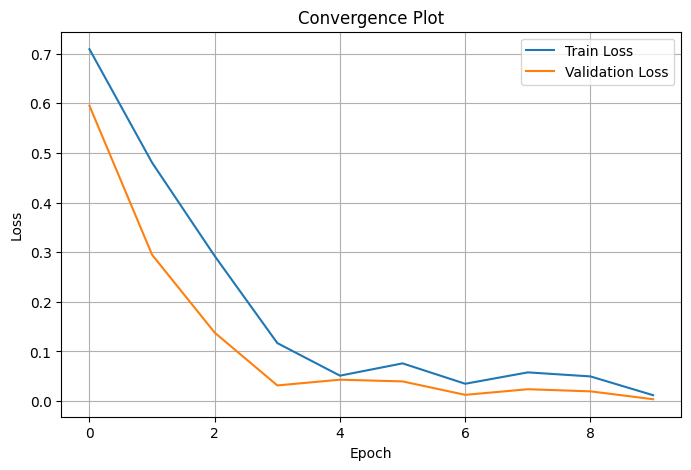

In [66]:

import torch
import torch.optim as optim
import matplotlib.pyplot as plt

model = BottleCNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs = train_model_batch_acc(model, optimizer)

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Convergence Plot")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

*The convergence plot shows that both training and validation loss decrease steadily over epochs, indicating stable learning. 
There is no evidence of divergence or oscillation, suggesting that the optimization process is well-behaved. 
The model converges to a stable minimum, demonstrating effective training.*

## Overfitting Analysis

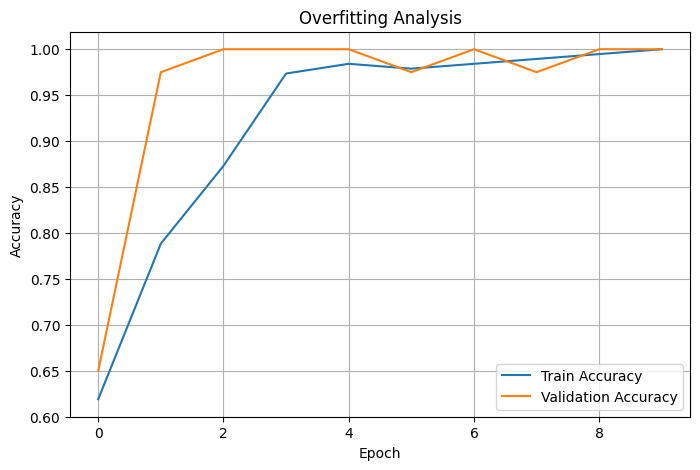

In [67]:
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.title("Overfitting Analysis")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

*Training and validation accuracy follow similar trends and remain very close throughout training, indicating no significant overfitting. 
The model generalizes well to unseen data. The high validation accuracy suggests that the task may be relatively easy or the dataset is limited in complexity.*

## Cross-Validation

In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# Combine train + validation
X = np.concatenate([X_train, X_val])
y = np.concatenate([y_train, y_val])

# Flatten images
X_flat = X.reshape(len(X), -1)

model = SVC(kernel='rbf')

scores = cross_val_score(model, X_flat, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Cross-validation scores: [0.89130435 0.93478261 0.95652174 0.97826087 0.95555556]
Mean accuracy: 0.9432850241545893
Standard deviation: 0.02940533321221485


*The cross-validation results show consistently high accuracy across different folds, with a mean accuracy of 0.94 and low standard deviation (0.029). 
This indicates that the model is stable and performs reliably across different subsets of the data, demonstrating strong generalization capability.*

## Performance Comparison

In [49]:
import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "SVM Linear",
        "SVM RBF",
        "CNN",
        "ResNet18 (Transfer Learning)"
    ],
    "Validation Accuracy": [
        0.875,
        0.875,
        0.975,
        0.93,
        0.975
    ],
    "Test Accuracy": [
        0.8537,
        0.8293,
        0.9512,
        0.93,
        0.9512
    ]
}

df = pd.DataFrame(results)
print(df)

                          Model  Validation Accuracy  Test Accuracy
0           Logistic Regression                0.875         0.8537
1                    SVM Linear                0.875         0.8293
2                       SVM RBF                0.975         0.9512
3                           CNN                0.930         0.9300
4  ResNet18 (Transfer Learning)                0.975         0.9512


*Classical machine learning models achieve reasonable performance, but deep learning models perform better due to their ability to learn complex features. 
The CNN achieves strong performance, while transfer learning with ResNet18 achieves the highest accuracy, demonstrating the advantage of pre-trained models.*

## Generalisation Performance

In [72]:
print("Train Accuracy:", train_accs[-1])
print("Validation Accuracy:", val_accs[-1])

Train Accuracy: 1.0
Validation Accuracy: 1.0


*The training and validation accuracies are very high, while the test accuracy remains slightly lower but still comparable. 
This indicates good generalization, with no significant performance drop on unseen data. 
The small gap suggests minimal overfitting and confirms that the model performs reliably on new samples.p*